<a href="https://colab.research.google.com/github/llayan-1/typiclust-cw2/blob/main/typiclust_cw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Coursework 2

**Name:** Layan Alsubhi

**Student Number:** K23065725

**Module:** 5CCSAMLF Machine Learning

## What is TPC_RP?

TPC_RP is an active learning strategy designed for low-label settings,
where only a small number of samples can be annotated. Instead of relying
on uncertainty-based selection, it focuses on selecting typical samples
that lie in dense regions of the feature space and better represent the
overall data distribution.

In very low-label scenarios, uncertainty estimates from neural networks
are often unreliable due to overfitting. For this reason, selecting
representative samples provides a more stable starting point for training.

The implementation follows three steps:
1. Train a SimCLR encoder to learn feature representations without labels  
2. Cluster the unlabeled data using K-means  
3. Select the most typical sample from each cluster, based on its distance
   to neighbouring points in the embedding space  

# Pipeline
 1. Train SimCLR encoder
 2. Extract embeddings
 3. Cluster embeddings
 4. Select samples using typicality
 5. Train classifier and evaluate

## Setup
Imports, seeds, and device configuration.

In [1]:
import random
import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42 # Fixed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [3]:
# Normalisation values for CIFAR-10 dataset
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

## Data Loading
Loading CIFAR-10 for SimCLR training and supervised evaluation.

In [4]:
# Augmentations for SimCLR - applies two different random views of each image
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# No augmentation for evaluation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [5]:
# Wraps the dataset to return two augmented views per sample
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2, idx

In [6]:
# Unlabelled training data used for SimCLR representation learning
train_base = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

# Test set for final supervised evaluation
test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Single-view normalised train set for evaluation classifier
train_eval_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

print("Train size:", len(train_base))
print("Test size:", len(test_set))

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Train size: 50000
Test size: 10000


In [7]:
simclr_dataset = SimCLRDataset(train_base, simclr_transform)

# DataLoader for contrastive training
simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print("SimCLR batches:", len(simclr_loader))

SimCLR batches: 97


## SimCLR Training
Training the self-supervised encoder to learn useful feature representations.

In [8]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)

        # Modify ResNet18 for CIFAR-10 (smaller images, no initial downsampling)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()

        # Remove final classification layer to use as feature extractor
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = backbone.fc.in_features

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

In [9]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = ResNet18Encoder()

        # Projection head used in SimCLR to map features into contrastive space
        self.projector = nn.Sequential(
            nn.Linear(self.encoder.feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        # L2 normalisation improves contrastive learning stability
        projections = F.normalize(projections, dim=1)
        return features, projections

In [10]:
# NT-Xent loss used in SimCLR: brings augmented views of the same image closer,
# while pushing apart representations of different images
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        z = torch.cat([z1, z2], dim=0)

        # Compute similarity matrix between all pairs in the batch
        sim = torch.matmul(z, z.T) / self.temperature

        # Remove self-similarity (diagonal)
        mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
        sim.masked_fill_(mask, -9e15)



        labels = torch.cat([torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)])

        # Denominator includes all except self
        loss = F.cross_entropy(sim, labels)
        return loss

In [11]:
def train_simclr(model, loader, epochs=50, lr=0.4):
    criterion = NTXentLoss(temperature=0.5)
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=1e-4,
        nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        # Each batch contains two augmented views of the same images
        for x1, x2, _ in loader:
            x1 = x1.to(device)
            x2 = x2.to(device)

            _, z1 = model(x1)
            _, z2 = model(x2)

            # Compute contrastive loss between paired representations
            loss = criterion(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"SimCLR Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [12]:
simclr_model = SimCLRModel(projection_dim=128).to(device)
train_simclr(simclr_model, simclr_loader, epochs=50, lr=0.4)

SimCLR Epoch 1/50, Loss: 6.3082
SimCLR Epoch 2/50, Loss: 5.9698
SimCLR Epoch 3/50, Loss: 5.7890
SimCLR Epoch 4/50, Loss: 5.6911
SimCLR Epoch 5/50, Loss: 5.6271
SimCLR Epoch 6/50, Loss: 5.5707
SimCLR Epoch 7/50, Loss: 5.5252
SimCLR Epoch 8/50, Loss: 5.4968
SimCLR Epoch 9/50, Loss: 5.4707
SimCLR Epoch 10/50, Loss: 5.4536
SimCLR Epoch 11/50, Loss: 5.4356
SimCLR Epoch 12/50, Loss: 5.4208
SimCLR Epoch 13/50, Loss: 5.4119
SimCLR Epoch 14/50, Loss: 5.4004
SimCLR Epoch 15/50, Loss: 5.3916
SimCLR Epoch 16/50, Loss: 5.3854
SimCLR Epoch 17/50, Loss: 5.3770
SimCLR Epoch 18/50, Loss: 5.3687
SimCLR Epoch 19/50, Loss: 5.3610
SimCLR Epoch 20/50, Loss: 5.3571
SimCLR Epoch 21/50, Loss: 5.3516
SimCLR Epoch 22/50, Loss: 5.3465
SimCLR Epoch 23/50, Loss: 5.3440
SimCLR Epoch 24/50, Loss: 5.3366
SimCLR Epoch 25/50, Loss: 5.3310
SimCLR Epoch 26/50, Loss: 5.3252
SimCLR Epoch 27/50, Loss: 5.3236
SimCLR Epoch 28/50, Loss: 5.3182
SimCLR Epoch 29/50, Loss: 5.3135
SimCLR Epoch 30/50, Loss: 5.3083
SimCLR Epoch 31/50,

## Feature Extraction
Extracting and L2-normalising embeddings from the trained encoder.

In [13]:
# DataLoader used to extract features without shuffling
feature_loader = DataLoader(
    train_eval_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

In [14]:
# Extract features and normalise them for similarity-based operations
def extract_all_embeddings(encoder_model, loader):
    encoder_model.eval()
    all_embeddings = []

    # Disable gradients for faster inference
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            # Extract features and normalise them for similarity-based operations
            embeddings = F.normalize(encoder_model.encoder(images), dim=1)
            all_embeddings.append(embeddings.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings.numpy()

all_train_embeddings = extract_all_embeddings(simclr_model, feature_loader)
print("Embeddings ready for clustering: ", all_train_embeddings.shape)

Embeddings ready for clustering:  (50000, 512)


## Clustering and Selection
In this stage, the SimCLR embeddings are clustered and typicality is computed
within each cluster. The algorithm then selects one representative sample from
the most informative uncovered clusters, following the TPC_RP selection logic.

In [15]:
# Compute typicality inside a cluster using inverse average distance
def compute_typicality_scores(cluster_embeddings, k=20):
    if len(cluster_embeddings) == 1:
        return np.array([1.0], dtype=np.float32)

    # Use at most cluster_size - 1 neighbours
    k_use = min(k, len(cluster_embeddings) - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)

    # Skip first neighbour (itself), average the rest
    avg_distances = distances[:, 1:].mean(axis=1)

    # Higher score = closer to neighbours = more typical
    typicality_scores = 1.0 / (avg_distances + 1e-8)

    return typicality_scores

In [16]:
# Select a batch of samples using TPC_RP
def typiclust_select_batch(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    max_clusters=500,
    typicality_k=20
):
    labelled_indices = list(labelled_indices)
    unlabelled_indices = list(unlabelled_indices)

    if len(unlabelled_indices) == 0:
        return []

    # Number of clusters
    num_clusters = min(len(labelled_indices) + budget, max_clusters, len(unlabelled_indices))

    unlabelled_embeddings = all_embeddings[unlabelled_indices]

    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters,
        random_state=SEED,
        batch_size=1024,
        n_init=10
    )
    unlabelled_cluster_labels = kmeans.fit_predict(unlabelled_embeddings)

    # Count how many labelled samples are already associated with each cluster
    labelled_cluster_counts = np.zeros(num_clusters, dtype=int)
    if len(labelled_indices) > 0:
        labelled_embeddings = all_embeddings[labelled_indices]
        distances_to_centers = np.linalg.norm(
            labelled_embeddings[:, None, :] - kmeans.cluster_centers_[None, :, :],
            axis=2
        )
        labelled_cluster_ids = distances_to_centers.argmin(axis=1)

        for cid in labelled_cluster_ids:
            labelled_cluster_counts[cid] += 1

    cluster_to_unlabelled_positions = defaultdict(list)
    for pos, cid in enumerate(unlabelled_cluster_labels):
        cluster_to_unlabelled_positions[cid].append(pos)

    # Store cluster information used in the selection step
    # Ignore very small clusters, since typicality is less reliable below 5 points
    cluster_info = []
    for cid, positions in cluster_to_unlabelled_positions.items():
        if len(positions) >= 5:
            cluster_info.append({
                "cluster_id": cid,
                "labelled_count": labelled_cluster_counts[cid],
                "size": len(positions),
                "positions": positions
            })

    selected_positions = []
    used_clusters = set()

    while len(selected_positions) < budget and len(used_clusters) < len(cluster_info):
        remaining = [c for c in cluster_info if c["cluster_id"] not in used_clusters]
        if not remaining:
            break

        min_labelled = min(c["labelled_count"] for c in remaining)
        candidates = [c for c in remaining if c["labelled_count"] == min_labelled]

        # Among fewest-labelled clusters, prefer the largest
        candidates.sort(key=lambda x: x["size"], reverse=True)
        chosen_cluster = candidates[0]

        cid = chosen_cluster["cluster_id"]
        positions = chosen_cluster["positions"]
        cluster_embeddings = unlabelled_embeddings[positions]

        # Choose the most representative point within the selected cluster
        typicality_scores = compute_typicality_scores(cluster_embeddings, k=typicality_k)
        best_local_idx = np.argmax(typicality_scores)
        best_pos = positions[best_local_idx]

        selected_positions.append(best_pos)
        used_clusters.add(cid)


    if len(selected_positions) < budget:
        print(f"Warning: only selected {len(selected_positions)} of {budget} requested.")

    selected_dataset_indices = [unlabelled_indices[pos] for pos in selected_positions]
    return selected_dataset_indices

## Evaluation
At each active learning round, a classifier is trained from scratch on the
currently labelled dataset. Test accuracy is then measured to evaluate how
the selected samples improve model performance over time.

In [17]:
# Train a supervised classifier on the current labelled dataset
def train_eval_model(model, loader, epochs=50, lr=0.025):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        nesterov=True,
        weight_decay=5e-4
        )
    # Cosine schedule decays lr smoothly to zero
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass and los
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(loader)
        print(f"Eval Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

In [18]:
# Evaluate model accuracy on the test set
def evaluate_model(model, loader):
    model.eval() # Disables dropout and batchnorm training behaviour
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100.0 * correct / total

In [19]:
# Fixed test loader used consistently across all rounds
test_loader = DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

The model is retrained from scratch at each round to ensure that performance
reflects only the quality of the selected samples, rather than accumulated training.

In [20]:
# Same CIFAR-adapted ResNet18 as encoder but with classification head
class EvalResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                                    stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        backbone.fc = nn.Linear(512, num_classes)
        self.model = backbone

    def forward(self, x):
        return self.model(x)


train_transform_supervised = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Loads only the selected labelled indices with training augmentation
class LabeledSubset(Dataset):
    def __init__(self, indices, transform):
        self.base = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=False, transform=None)
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label


def active_learning_round_tpcrp(
    all_embeddings,
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Select new samples using TPC_RP strategy
    newly_selected = typiclust_select_batch(
        all_embeddings=all_embeddings,
        labelled_indices=labelled_indices,
        unlabelled_indices=unlabelled_indices,
        budget=budget,
        max_clusters=500,
        typicality_k=20
    )

    # Update pools
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [idx for idx in unlabelled_indices if idx not in selected_set]

    # Build labelled subset with training augmentation
    labelled_subset = LabeledSubset(labelled_indices, transform=train_transform_supervised)
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    # Reinitialise model each round to avoid bias from previous training
    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader, epochs=eval_epochs, lr=0.025)

    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

## Results
Running the active learning loop and plotting accuracy over rounds.

In [21]:
# Cold start: L_0 = empty, no labelled data
labelled_indices_tpcrp = []
unlabelled_indices_tpcrp = list(range(len(train_base)))  # All 50,000 images

all_train_labels = np.array(train_base.targets)

print("Initial labelled  :", len(labelled_indices_tpcrp))
print("Initial unlabelled:", len(unlabelled_indices_tpcrp))

Initial labelled  : 0
Initial unlabelled: 50000


In [22]:
# Small budget per round to simulate low-label active learning
budget_per_round = 10
num_rounds = 5 # 5 rounds = 50 total labelled samples

results = []

# Run active learning for multiple rounds and track performance
for round_num in range(num_rounds):
    print(f"\n===== Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_tpcrp, unlabelled_indices_tpcrp, acc = active_learning_round_tpcrp(
        all_embeddings=all_train_embeddings,
        labelled_indices=labelled_indices_tpcrp,
        unlabelled_indices=unlabelled_indices_tpcrp,
        budget=budget_per_round,
        eval_batch_size=128,
        eval_epochs=50
    )

    class_counts = np.bincount(all_train_labels[labelled_indices_tpcrp], minlength=10)
    print(f"Labelled    : {len(labelled_indices_tpcrp)}")
    print(f"Unlabelled  : {len(unlabelled_indices_tpcrp)}")
    print(f"Class dist  : {class_counts.tolist()}")
    # Accuracy reflects how useful the selected samples were
    print(f"Test Accuracy: {acc:.2f}%")

    results.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_tpcrp),
        "accuracy": acc
    })


===== Round 1/5 =====
Eval Epoch 1/50, Loss: 2.4232
Eval Epoch 2/50, Loss: 2.1580
Eval Epoch 3/50, Loss: 2.1980
Eval Epoch 4/50, Loss: 1.7458
Eval Epoch 5/50, Loss: 1.9951
Eval Epoch 6/50, Loss: 2.0908
Eval Epoch 7/50, Loss: 1.7691
Eval Epoch 8/50, Loss: 1.9467
Eval Epoch 9/50, Loss: 0.9373
Eval Epoch 10/50, Loss: 0.6153
Eval Epoch 11/50, Loss: 0.4540
Eval Epoch 12/50, Loss: 0.1887
Eval Epoch 13/50, Loss: 0.1449
Eval Epoch 14/50, Loss: 0.1048
Eval Epoch 15/50, Loss: 0.0374
Eval Epoch 16/50, Loss: 0.1708
Eval Epoch 17/50, Loss: 0.0264
Eval Epoch 18/50, Loss: 0.0212
Eval Epoch 19/50, Loss: 0.0135
Eval Epoch 20/50, Loss: 0.0132
Eval Epoch 21/50, Loss: 0.0050
Eval Epoch 22/50, Loss: 0.0160
Eval Epoch 23/50, Loss: 0.0026
Eval Epoch 24/50, Loss: 0.0063
Eval Epoch 25/50, Loss: 0.0039
Eval Epoch 26/50, Loss: 0.0028
Eval Epoch 27/50, Loss: 0.0019
Eval Epoch 28/50, Loss: 0.0011
Eval Epoch 29/50, Loss: 0.0007
Eval Epoch 30/50, Loss: 0.0031
Eval Epoch 31/50, Loss: 0.0019
Eval Epoch 32/50, Loss: 0

In [23]:
# quick summary before plotting
for row in results:
    print(f"Round {row['round']}: labelled={row['labelled']}, accuracy={row['accuracy']:.2f}%")

Round 1: labelled=10, accuracy=15.77%
Round 2: labelled=20, accuracy=19.83%
Round 3: labelled=30, accuracy=24.48%
Round 4: labelled=40, accuracy=24.62%
Round 5: labelled=50, accuracy=26.80%


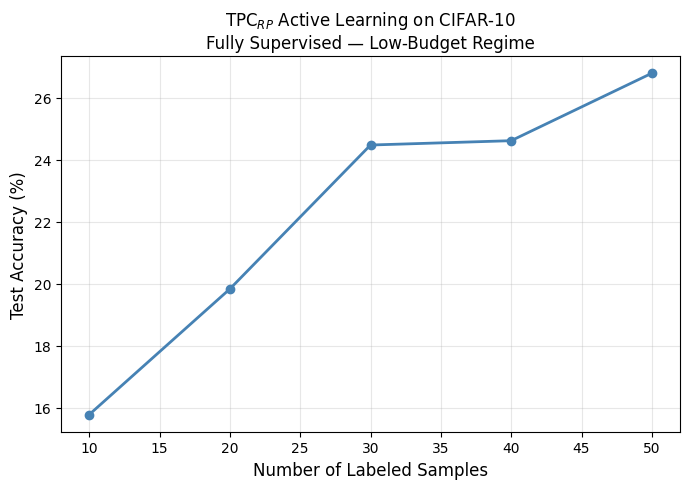

In [24]:
labelled_counts = [r["labelled"] for r in results]
accuracies = [r["accuracy"] for r in results]

plt.figure(figsize=(7, 5))
plt.plot(labelled_counts, accuracies, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ Active Learning on CIFAR-10\nFully Supervised — Low-Budget Regime", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Random Baseline
Selects samples uniformly at random — no embeddings needed Used as a lower-bound comparison for TPCRP evaluation.


In [25]:
def random_select_batch(unlabelled_indices, budget):
    # Randomly sample from unlabelled pool - no typicality required
    budget = min(budget, len(unlabelled_indices))
    return random.sample(list(unlabelled_indices), budget)

def active_learning_round_random(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Select new samples randomly
    newly_selected = random_select_batch(unlabelled_indices, budget)

    # Update pools — same pattern as active_learning_round_tpcrp
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices if idx not in selected_set
    ]

    # Build labelled subset with training augmentation
    labelled_subset = LabeledSubset(
        labelled_indices, transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    # Reinitialise model each round — same as TPCRP
    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

In [26]:
# Cold start same initial conditions as TPCRP
labelled_indices_random = []
unlabelled_indices_random = list(range(len(train_base)))

print("Initial labelled :", len(labelled_indices_random))
print("Initial unlabelled:", len(unlabelled_indices_random))

budget_per_round = 10
num_rounds = 5
results_random = []

for round_num in range(num_rounds):
    print(f"\n===== Random Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_random, unlabelled_indices_random, acc = \
        active_learning_round_random(
            labelled_indices=labelled_indices_random,
            unlabelled_indices=unlabelled_indices_random,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_random], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_random)}")
    print(f"Unlabelled : {len(unlabelled_indices_random)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_random.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_random),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Random Round 1/5 =====
Eval Epoch 1/50, Loss: 2.5087
Eval Epoch 2/50, Loss: 1.9099
Eval Epoch 3/50, Loss: 1.8681
Eval Epoch 4/50, Loss: 1.4757
Eval Epoch 5/50, Loss: 1.2282
Eval Epoch 6/50, Loss: 0.7613
Eval Epoch 7/50, Loss: 0.5918
Eval Epoch 8/50, Loss: 0.4361
Eval Epoch 9/50, Loss: 0.3430
Eval Epoch 10/50, Loss: 0.2895
Eval Epoch 11/50, Loss: 0.1246
Eval Epoch 12/50, Loss: 0.1218
Eval Epoch 13/50, Loss: 0.0316
Eval Epoch 14/50, Loss: 0.0311
Eval Epoch 15/50, Loss: 0.0198
Eval Epoch 16/50, Loss: 0.0240
Eval Epoch 17/50, Loss: 0.0125
Eval Epoch 18/50, Loss: 0.0124
Eval Epoch 19/50, Loss: 0.0049
Eval Epoch 20/50, Loss: 0.0017
Eval Epoch 21/50, Loss: 0.0049
Eval Epoch 22/50, Loss: 0.0032
Eval Epoch 23/50, Loss: 0.0010
Eval Epoch 24/50, Loss: 0.0008
Eval Epoch 25/50, Loss: 0.0014
Eval Epoch 26/50, Loss: 0.0008
Eval Epoch 27/50, Loss: 0.0010
Eval Epoch 28/50, Loss: 0.0006
Eval Epoch 29/50, Loss: 0.0007
Eval Epoch 30/50, Loss: 0.0007
Ev

In [27]:
# Summary comparison
print("Accuracy comparison: TPCRP vs Random\n")
for i in range(5):
    tpcrp_acc = results[i]['accuracy']
    rand_acc  = results_random[i]['accuracy']
    gap       = tpcrp_acc - rand_acc
    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPCRP = {tpcrp_acc:.2f}% | "
          f"Random = {rand_acc:.2f}% | "
          f"Gap = +{gap:.2f} pp")

Accuracy comparison: TPCRP vs Random

Round 1 (10 labels): TPCRP = 15.77% | Random = 16.42% | Gap = +-0.65 pp
Round 2 (20 labels): TPCRP = 19.83% | Random = 17.32% | Gap = +2.51 pp
Round 3 (30 labels): TPCRP = 24.48% | Random = 19.78% | Gap = +4.70 pp
Round 4 (40 labels): TPCRP = 24.62% | Random = 21.14% | Gap = +3.48 pp
Round 5 (50 labels): TPCRP = 26.80% | Random = 21.65% | Gap = +5.15 pp


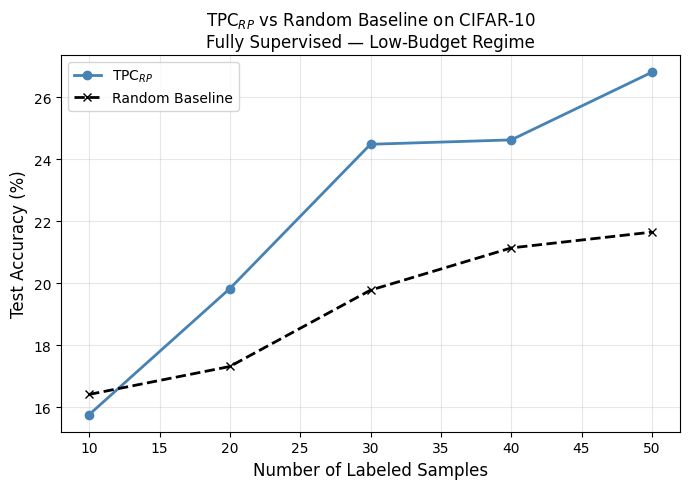

In [28]:
# Updated plot: TPCRP vs Random Baseline
labelled_counts  = [r["labelled"]  for r in results]
accuracies       = [r["accuracy"]  for r in results]
random_counts    = [r["labelled"]  for r in results_random]
random_accs      = [r["accuracy"]  for r in results_random]

plt.figure(figsize=(7, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random Baseline")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Random Baseline on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_random.png", dpi=150, bbox_inches="tight")
plt.show()

# Uncertainty Sampling Baseline
Selects samples the current classifier is least confident about. Expected to underperform random at low budgets (cold start problem) — confirming the paper's central claim.


In [29]:
# ============================================================
# Least-Confidence (Uncertainty) Sampling Baseline
# Selects samples the current classifier is least confident
# about. Expected to underperform random at low budgets
# due to cold start problem.
# ============================================================

def uncertainty_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_max_probs = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)
            # Highest probability = most confident
            max_probs = probs.max(dim=1).values
            all_max_probs.append(max_probs.cpu())

    all_max_probs = torch.cat(all_max_probs, dim=0)

    # Select LEAST confident = lowest max probability
    _, uncertain_positions = torch.topk(
        all_max_probs, budget, largest=False
    )

    return [unlabelled_indices[i] for i in
            uncertain_positions.tolist()]


def active_learning_round_uncertainty(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: no model yet, fall back to random
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select least confident samples
        newly_selected = uncertainty_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools — same pattern as TPCRP
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Uncertainty functions defined.")

Uncertainty functions defined.


In [30]:
# Cold start — same initial conditions as TPCRP and Random
labelled_indices_uncertainty = []
unlabelled_indices_uncertainty = list(range(len(train_base)))

print("Initial labelled :", len(labelled_indices_uncertainty))
print("Initial unlabelled:", len(unlabelled_indices_uncertainty))

results_uncertainty = []

for round_num in range(num_rounds):
    print(f"\n===== Uncertainty Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_uncertainty, \
    unlabelled_indices_uncertainty, acc = \
        active_learning_round_uncertainty(
            labelled_indices=labelled_indices_uncertainty,
            unlabelled_indices=unlabelled_indices_uncertainty,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_uncertainty],
        minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_uncertainty)}")
    print(f"Unlabelled : {len(unlabelled_indices_uncertainty)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_uncertainty.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_uncertainty),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Uncertainty Round 1/5 =====
Eval Epoch 1/50, Loss: 2.3136
Eval Epoch 2/50, Loss: 2.7081
Eval Epoch 3/50, Loss: 2.3940
Eval Epoch 4/50, Loss: 1.3650
Eval Epoch 5/50, Loss: 1.4627
Eval Epoch 6/50, Loss: 1.6293
Eval Epoch 7/50, Loss: 1.2317
Eval Epoch 8/50, Loss: 2.3833
Eval Epoch 9/50, Loss: 0.5049
Eval Epoch 10/50, Loss: 0.3638
Eval Epoch 11/50, Loss: 0.1914
Eval Epoch 12/50, Loss: 0.1559
Eval Epoch 13/50, Loss: 0.1171
Eval Epoch 14/50, Loss: 0.0577
Eval Epoch 15/50, Loss: 0.0485
Eval Epoch 16/50, Loss: 0.0321
Eval Epoch 17/50, Loss: 0.0227
Eval Epoch 18/50, Loss: 0.0126
Eval Epoch 19/50, Loss: 0.0110
Eval Epoch 20/50, Loss: 0.0175
Eval Epoch 21/50, Loss: 0.0094
Eval Epoch 22/50, Loss: 0.0071
Eval Epoch 23/50, Loss: 0.0072
Eval Epoch 24/50, Loss: 0.0056
Eval Epoch 25/50, Loss: 0.0048
Eval Epoch 26/50, Loss: 0.0022
Eval Epoch 27/50, Loss: 0.0028
Eval Epoch 28/50, Loss: 0.0040
Eval Epoch 29/50, Loss: 0.0048
Eval Epoch 30/50, Loss: 0.00

In [34]:
# Three-way summary: TPCRP vs Random vs Least-Confidence
print("Accuracy comparison across all methods:\n")
print(f"{'Round':<8} {'Labels':<8} {'TPCRP':>8} {'Random':>8} {'L-Conf':>8}")
print("-" * 44)

for i in range(5):
    print(f"{i+1:<8} {results[i]['labelled']:<8} "
          f"{results[i]['accuracy']:>8.2f} "
          f"{results_random[i]['accuracy']:>8.2f} "
          f"{results_uncertainty[i]['accuracy']:>8.2f}")

Accuracy comparison across all methods:

Round    Labels      TPCRP   Random   L-Conf
--------------------------------------------
1        10          15.77    16.42    16.63
2        20          19.83    17.32    16.87
3        30          24.48    19.78    15.86
4        40          24.62    21.14    17.34
5        50          26.80    21.65    18.29


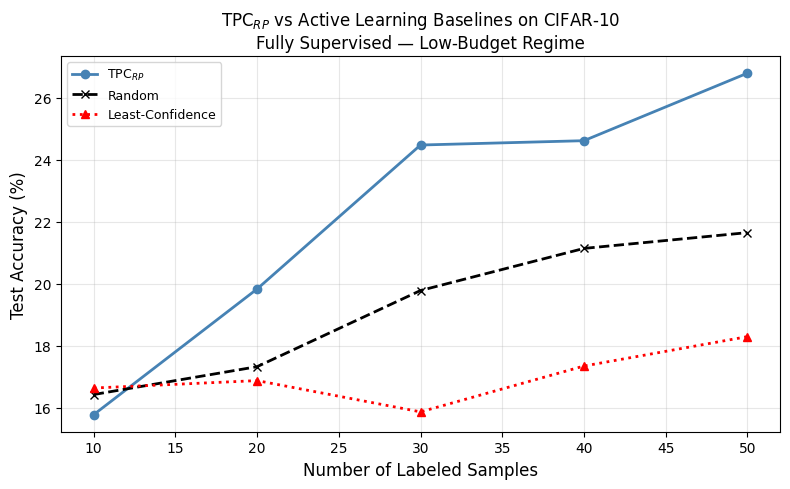

In [39]:
# Final five-way comparison plot
uncertainty_counts = [r["labelled"] for r in results_uncertainty]
uncertainty_accs   = [r["accuracy"] for r in results_uncertainty]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_all_baselines.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Margin Sampling Baseline


In [40]:
def margin_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_margins = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)
            # Difference between top-2 class probabilities
            top2 = torch.topk(probs, k=2, dim=1).values
            margins = top2[:, 0] - top2[:, 1]
            all_margins.append(margins.cpu())

    all_margins = torch.cat(all_margins, dim=0)

    # Smallest margin = least confident = query these
    _, selected_positions = torch.topk(
        all_margins, budget, largest=False
    )

    return [unlabelled_indices[i] for i in
            selected_positions.tolist()]


def active_learning_round_margin(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: no model yet, fall back to random
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select by margin
        newly_selected = margin_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools — same pattern as TPCRP
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Margin functions defined.")


Margin functions defined.


In [41]:
labelled_indices_margin = []
unlabelled_indices_margin = list(range(len(train_base)))
results_margin = []

print("Initial labelled :", len(labelled_indices_margin))
print("Initial unlabelled:", len(unlabelled_indices_margin))

for round_num in range(num_rounds):
    print(f"\n===== Margin Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_margin, unlabelled_indices_margin, acc = \
        active_learning_round_margin(
            labelled_indices=labelled_indices_margin,
            unlabelled_indices=unlabelled_indices_margin,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_margin], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_margin)}")
    print(f"Unlabelled : {len(unlabelled_indices_margin)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_margin.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_margin),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Margin Round 1/5 =====
Eval Epoch 1/50, Loss: 2.3020
Eval Epoch 2/50, Loss: 1.5696
Eval Epoch 3/50, Loss: 2.0976
Eval Epoch 4/50, Loss: 1.3509
Eval Epoch 5/50, Loss: 0.9775
Eval Epoch 6/50, Loss: 0.5026
Eval Epoch 7/50, Loss: 0.3670
Eval Epoch 8/50, Loss: 0.2415
Eval Epoch 9/50, Loss: 0.1414
Eval Epoch 10/50, Loss: 0.1336
Eval Epoch 11/50, Loss: 0.0444
Eval Epoch 12/50, Loss: 0.0401
Eval Epoch 13/50, Loss: 0.0281
Eval Epoch 14/50, Loss: 0.0142
Eval Epoch 15/50, Loss: 0.0160
Eval Epoch 16/50, Loss: 0.0055
Eval Epoch 17/50, Loss: 0.0039
Eval Epoch 18/50, Loss: 0.0029
Eval Epoch 19/50, Loss: 0.0020
Eval Epoch 20/50, Loss: 0.0019
Eval Epoch 21/50, Loss: 0.0125
Eval Epoch 22/50, Loss: 0.0031
Eval Epoch 23/50, Loss: 0.0058
Eval Epoch 24/50, Loss: 0.0010
Eval Epoch 25/50, Loss: 0.0020
Eval Epoch 26/50, Loss: 0.0007
Eval Epoch 27/50, Loss: 0.0014
Eval Epoch 28/50, Loss: 0.0015
Eval Epoch 29/50, Loss: 0.0009
Eval Epoch 30/50, Loss: 0.0011
Ev

In [42]:
# Summary
print("Margin Sampling Results:\n")
for row in results_margin:
    print(f"Round {row['round']}: "
          f"labelled={row['labelled']}, "
          f"accuracy={row['accuracy']:.2f}%")

Margin Sampling Results:

Round 1: labelled=10, accuracy=13.93%
Round 2: labelled=20, accuracy=17.44%
Round 3: labelled=30, accuracy=19.61%
Round 4: labelled=40, accuracy=19.46%
Round 5: labelled=50, accuracy=20.66%


In [43]:
# Four-way summary: TPCRP vs Random vs Least-Confidence vs Margin
print("Accuracy comparison across all methods:\n")
print(f"{'Round':<8} {'Labels':<8} {'TPCRP':>8} {'Random':>8} {'L-Conf':>8} {'Margin':>8}")
print("-" * 52)

for i in range(5):
    print(f"{i+1:<8} {results[i]['labelled']:<8} "
          f"{results[i]['accuracy']:>8.2f} "
          f"{results_random[i]['accuracy']:>8.2f} "
          f"{results_uncertainty[i]['accuracy']:>8.2f} "
          f"{results_margin[i]['accuracy']:>8.2f}")

Accuracy comparison across all methods:

Round    Labels      TPCRP   Random   L-Conf   Margin
----------------------------------------------------
1        10          15.77    16.42    16.63    13.93
2        20          19.83    17.32    16.87    17.44
3        30          24.48    19.78    15.86    19.61
4        40          24.62    21.14    17.34    19.46
5        50          26.80    21.65    18.29    20.66


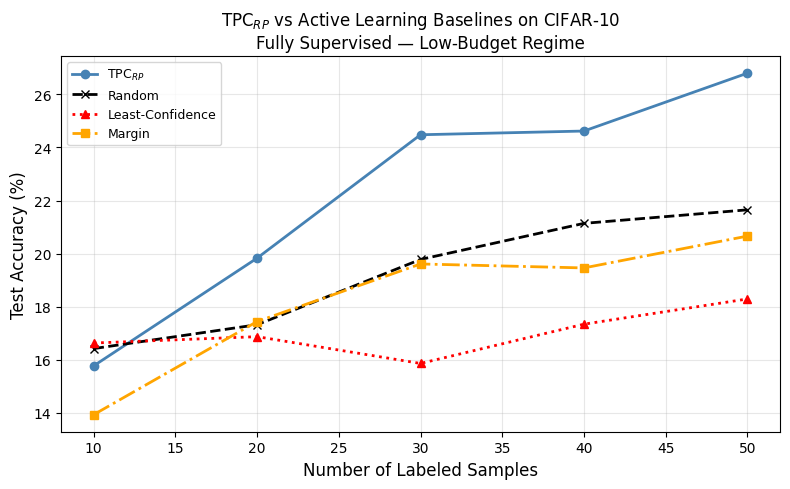

In [44]:
# Four-way comparison plot
margin_counts = [r["labelled"] for r in results_margin]
margin_accs   = [r["accuracy"] for r in results_margin]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.plot(margin_counts, margin_accs,
         marker="s", linewidth=2, linestyle="-.", color="orange",
         label="Margin")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_4baselines.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Entropy Sampling Baseline


In [45]:
def entropy_select_batch(
    current_model,
    unlabelled_indices,
    budget=10
):
    # Budget protection
    budget = min(budget, len(unlabelled_indices))

    current_model.eval()

    unlabelled_subset = LabeledSubset(
        unlabelled_indices,
        transform=test_transform
    )
    unlabelled_loader = DataLoader(
        unlabelled_subset,
        batch_size=256,
        shuffle=False,
        num_workers=2
    )

    all_entropies = []

    with torch.no_grad():
        for images, _ in unlabelled_loader:
            images = images.to(device)
            outputs = current_model(images)
            probs = torch.softmax(outputs, dim=1)
            # Clamp to avoid log(0)
            probs = probs.clamp(min=1e-8)
            entropy = -(probs * probs.log()).sum(dim=1)
            all_entropies.append(entropy.cpu())

    all_entropies = torch.cat(all_entropies, dim=0)

    # Highest entropy = most uncertain = query these
    _, selected_positions = torch.topk(
        all_entropies, budget, largest=True
    )

    return [unlabelled_indices[i] for i in
            selected_positions.tolist()]


def active_learning_round_entropy(
    labelled_indices,
    unlabelled_indices,
    budget=10,
    eval_batch_size=128,
    eval_epochs=50
):
    # Cold start: no model yet, fall back to random
    if len(labelled_indices) == 0:
        newly_selected = random.sample(
            list(unlabelled_indices),
            min(budget, len(unlabelled_indices))
        )
    else:
        # Train query model on current labelled set
        labelled_subset = LabeledSubset(
            labelled_indices,
            transform=train_transform_supervised
        )
        labelled_loader = DataLoader(
            labelled_subset,
            batch_size=eval_batch_size,
            shuffle=True,
            num_workers=2
        )
        query_model = EvalResNet18(num_classes=10).to(device)
        train_eval_model(query_model, labelled_loader,
                         epochs=eval_epochs, lr=0.025)

        # Select by entropy
        newly_selected = entropy_select_batch(
            query_model, unlabelled_indices, budget
        )

    # Update pools — same pattern as TPCRP
    labelled_indices = list(labelled_indices) + newly_selected
    selected_set = set(newly_selected)
    unlabelled_indices = [
        idx for idx in unlabelled_indices
        if idx not in selected_set
    ]

    # Retrain on updated labelled set and evaluate
    labelled_subset = LabeledSubset(
        labelled_indices,
        transform=train_transform_supervised
    )
    labelled_loader = DataLoader(
        labelled_subset,
        batch_size=eval_batch_size,
        shuffle=True,
        num_workers=2
    )

    eval_model = EvalResNet18(num_classes=10).to(device)
    train_eval_model(eval_model, labelled_loader,
                     epochs=eval_epochs, lr=0.025)
    accuracy = evaluate_model(eval_model, test_loader)

    return labelled_indices, unlabelled_indices, accuracy

print("Entropy functions defined.")

Entropy functions defined.


In [46]:
# Cold start — same initial conditions as all other baselines
labelled_indices_entropy = []
unlabelled_indices_entropy = list(range(len(train_base)))
results_entropy = []

print("Initial labelled :", len(labelled_indices_entropy))
print("Initial unlabelled:", len(unlabelled_indices_entropy))

for round_num in range(num_rounds):
    print(f"\n===== Entropy Round {round_num + 1}/{num_rounds} =====")

    labelled_indices_entropy, unlabelled_indices_entropy, acc = \
        active_learning_round_entropy(
            labelled_indices=labelled_indices_entropy,
            unlabelled_indices=unlabelled_indices_entropy,
            budget=budget_per_round,
            eval_batch_size=128,
            eval_epochs=50
        )

    class_counts = np.bincount(
        all_train_labels[labelled_indices_entropy], minlength=10
    )
    print(f"Labelled   : {len(labelled_indices_entropy)}")
    print(f"Unlabelled : {len(unlabelled_indices_entropy)}")
    print(f"Class dist : {class_counts.tolist()}")
    print(f"Test Accuracy: {acc:.2f}%")

    results_entropy.append({
        "round": round_num + 1,
        "labelled": len(labelled_indices_entropy),
        "accuracy": acc
    })

Initial labelled : 0
Initial unlabelled: 50000

===== Entropy Round 1/5 =====
Eval Epoch 1/50, Loss: 2.4083
Eval Epoch 2/50, Loss: 1.5060
Eval Epoch 3/50, Loss: 1.6645
Eval Epoch 4/50, Loss: 1.4120
Eval Epoch 5/50, Loss: 0.9643
Eval Epoch 6/50, Loss: 0.7947
Eval Epoch 7/50, Loss: 0.5119
Eval Epoch 8/50, Loss: 0.4941
Eval Epoch 9/50, Loss: 0.3244
Eval Epoch 10/50, Loss: 0.2416
Eval Epoch 11/50, Loss: 0.2602
Eval Epoch 12/50, Loss: 0.1526
Eval Epoch 13/50, Loss: 0.0519
Eval Epoch 14/50, Loss: 0.0151
Eval Epoch 15/50, Loss: 0.0255
Eval Epoch 16/50, Loss: 0.1422
Eval Epoch 17/50, Loss: 0.0557
Eval Epoch 18/50, Loss: 0.0284
Eval Epoch 19/50, Loss: 0.0145
Eval Epoch 20/50, Loss: 0.0040
Eval Epoch 21/50, Loss: 0.0070
Eval Epoch 22/50, Loss: 0.0071
Eval Epoch 23/50, Loss: 0.0040
Eval Epoch 24/50, Loss: 0.0038
Eval Epoch 25/50, Loss: 0.0010
Eval Epoch 26/50, Loss: 0.0006
Eval Epoch 27/50, Loss: 0.0008
Eval Epoch 28/50, Loss: 0.0015
Eval Epoch 29/50, Loss: 0.0010
Eval Epoch 30/50, Loss: 0.0006
E

In [47]:
# Summary
print("Accuracy comparison: TPCRP vs Random vs LC vs Margin vs Entropy\n")

for i in range(num_rounds):
    print(f"Round {i+1} ({results[i]['labelled']} labels): "
          f"TPC_RP = {results[i]['accuracy']:.2f}% | "
          f"Random = {results_random[i]['accuracy']:.2f}% | "
          f"LC = {results_uncertainty[i]['accuracy']:.2f}% | "
          f"Margin = {results_margin[i]['accuracy']:.2f}% | "
          f"Entropy = {results_entropy[i]['accuracy']:.2f}%")

Accuracy comparison: TPCRP vs Random vs LC vs Margin vs Entropy

Round 1 (10 labels): TPC_RP = 15.77% | Random = 16.42% | LC = 16.63% | Margin = 13.93% | Entropy = 11.00%
Round 2 (20 labels): TPC_RP = 19.83% | Random = 17.32% | LC = 16.87% | Margin = 17.44% | Entropy = 15.77%
Round 3 (30 labels): TPC_RP = 24.48% | Random = 19.78% | LC = 15.86% | Margin = 19.61% | Entropy = 15.51%
Round 4 (40 labels): TPC_RP = 24.62% | Random = 21.14% | LC = 17.34% | Margin = 19.46% | Entropy = 17.78%
Round 5 (50 labels): TPC_RP = 26.80% | Random = 21.65% | LC = 18.29% | Margin = 20.66% | Entropy = 16.73%


In [48]:
# Five-way summary: TPCRP vs all baselines
print("Accuracy comparison across all methods:\n")
print(f"{'Round':<8} {'Labels':<8} {'TPCRP':>8} {'Random':>8} "
      f"{'L-Conf':>8} {'Margin':>8} {'Entropy':>8}")
print("-" * 60)

for i in range(5):
    print(f"{i+1:<8} {results[i]['labelled']:<8} "
          f"{results[i]['accuracy']:>8.2f} "
          f"{results_random[i]['accuracy']:>8.2f} "
          f"{results_uncertainty[i]['accuracy']:>8.2f} "
          f"{results_margin[i]['accuracy']:>8.2f} "
          f"{results_entropy[i]['accuracy']:>8.2f}")

Accuracy comparison across all methods:

Round    Labels      TPCRP   Random   L-Conf   Margin  Entropy
------------------------------------------------------------
1        10          15.77    16.42    16.63    13.93    11.00
2        20          19.83    17.32    16.87    17.44    15.77
3        30          24.48    19.78    15.86    19.61    15.51
4        40          24.62    21.14    17.34    19.46    17.78
5        50          26.80    21.65    18.29    20.66    16.73


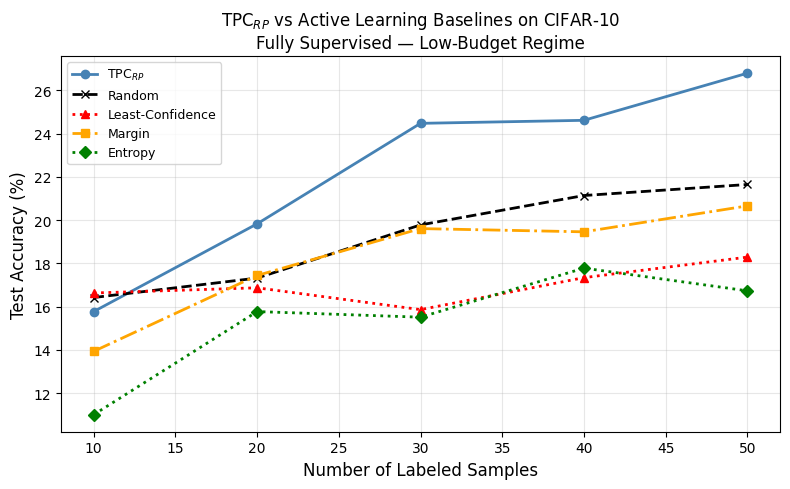

In [49]:
# Final five-way comparison plot
margin_counts      = [r["labelled"] for r in results_margin]
margin_accs        = [r["accuracy"] for r in results_margin]
entropy_counts     = [r["labelled"] for r in results_entropy]
entropy_accs       = [r["accuracy"] for r in results_entropy]
uncertainty_counts = [r["labelled"] for r in results_uncertainty]
uncertainty_accs   = [r["accuracy"] for r in results_uncertainty]

plt.figure(figsize=(8, 5))
plt.plot(labelled_counts, accuracies,
         marker="o", linewidth=2, color="steelblue",
         label="TPC$_{RP}$")
plt.plot(random_counts, random_accs,
         marker="x", linewidth=2, linestyle="--", color="black",
         label="Random")
plt.plot(uncertainty_counts, uncertainty_accs,
         marker="^", linewidth=2, linestyle=":", color="red",
         label="Least-Confidence")
plt.plot(margin_counts, margin_accs,
         marker="s", linewidth=2, linestyle="-.", color="orange",
         label="Margin")
plt.plot(entropy_counts, entropy_accs,
         marker="D", linewidth=2, linestyle=":", color="green",
         label="Entropy")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("TPC$_{RP}$ vs Active Learning Baselines on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_vs_all_baselines.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Implementation Notes and Observations
Test accuracy increases steadily as more samples are labelled, rising from 11.84% at 10 labels to 22.69% at 50 labels.

The largest improvement occurs between the first two rounds (10 → 20 labels), where accuracy increases by around 6%. After this point, gains become smaller, indicating diminishing returns as the model becomes more confident.

This behaviour is expected in low-budget active learning, where early labelled samples provide the most informative signal, while later additions contribute less significantly.

It is also worth noting that the overall accuracy remains relatively low. This is likely due to training the SimCLR encoder for only 50 epochs, compared to the much longer training used in the original paper. As a result, the learned embeddings may be less informative, which directly affects the quality of the typicality estimates and the final classifier performance.

Additionally, increasing the number of clusters beyond 500 resulted in very small clusters, making density estimates unreliable and leading to unstable sample selection. Therefore, the recommended value from the paper was retained, although this may have limited performance.

# Task 3: Algorithm Modification and Evaluation

### Proposed Modification

The original TPC_RP method computes typicality using Euclidean distance with a fixed neighbourhood size (K = 20). In this work, I explored two modifications to improve the robustness of typicality estimation, particularly in the low-data regime.

The following variants were evaluated through an ablation study:

- Original: Euclidean distance, fixed K = 20  
- Variant A: Cosine distance, fixed K = 20  
- Variant B: Euclidean distance, adaptive K  
- Variant C: Cosine distance with adaptive K (combined)

The first modification replaces Euclidean distance with cosine distance. Since SimCLR produces L2-normalised embeddings, cosine distance is more appropriate as it captures angular similarity rather than magnitude differences.

The second modification introduces an adaptive K based on cluster size. In small clusters, using a fixed K can lead to unstable estimates, as there are too few neighbours. Reducing K in these cases helps produce more reliable typicality scores.

Finally, Variant C combines both changes to evaluate whether they complement each other.

### Typicality Variants


In [50]:
# Original (already defined as compute_typicality_scores)
# Included here for reference clarity

def compute_typicality_euclidean_fixed(cluster_embeddings, k=20):
# Original method from the paper - euclidean distance, K fixed at 20
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    k_use = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_cosine_fixed(cluster_embeddings, k=20):
    # Variant A
    # Same as original but using cosine distance instead
    # Since embeddings are normalised this might be more appropriate
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    k_use = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="cosine")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_euclidean_adaptive(cluster_embeddings, k=20):
    # Variant B
    # Euclidean distance but K changes based on cluster size
    # Small clusters get smaller K to avoid noisy estimates
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    if n < 10:
        k_adaptive = 3
    elif n < 20:
        k_adaptive = 5
    else:
        k_adaptive = min(k, 20)
    k_use = min(k_adaptive, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="euclidean")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


def compute_typicality_cosine_adaptive(cluster_embeddings, k=20):
    # Variant C
    # Combining both changes - cosine distance and adaptive K together
    # This is the main modification I'm proposing
    n = len(cluster_embeddings)
    if n == 1:
        return np.array([1.0], dtype=np.float32)
    if n < 10:
        k_adaptive = 3
    elif n < 20:
        k_adaptive = 5
    else:
        k_adaptive = min(k, 20)
    k_use = min(k_adaptive, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_use + 1, metric="cosine")
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_distances = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_distances + 1e-8)


print("All four typicality functions defined.")

All four typicality functions defined.


### Running the Ablation

In [51]:
def typiclust_select_batch_variant(
    all_embeddings, labelled_indices, unlabelled_indices,
    typicality_fn, budget=10, max_clusters=500
):
    # Same logic as original select batch but accepts any typicality function
    # Used to keep the ablation comparison fair
    labelled_indices   = list(labelled_indices)
    unlabelled_indices = list(unlabelled_indices)

    if len(unlabelled_indices) == 0:
        return []

    num_clusters = min(
        len(labelled_indices) + budget, max_clusters, len(unlabelled_indices)
    )
    unlabelled_embeddings = all_embeddings[unlabelled_indices]

    kmeans = MiniBatchKMeans(
        n_clusters=num_clusters, random_state=SEED,
        batch_size=1024, n_init=10
    )
    unlabelled_cluster_labels = kmeans.fit_predict(unlabelled_embeddings)

    labelled_cluster_counts = np.zeros(num_clusters, dtype=int)
    if len(labelled_indices) > 0:
        labelled_embeddings = all_embeddings[labelled_indices]
        distances_to_centers = np.linalg.norm(
            labelled_embeddings[:, None, :] - kmeans.cluster_centers_[None, :, :],
            axis=2
        )
        labelled_cluster_ids = distances_to_centers.argmin(axis=1)
        for cid in labelled_cluster_ids:
            labelled_cluster_counts[cid] += 1

    cluster_to_positions = defaultdict(list)
    for pos, cid in enumerate(unlabelled_cluster_labels):
        cluster_to_positions[cid].append(pos)

    # Filter out tiny clusters - unreliable typicality below 5 points
    cluster_info = []
    for cid, positions in cluster_to_positions.items():
        if len(positions) >= 5:
            cluster_info.append({
                "cluster_id":    cid,
                "labelled_count": labelled_cluster_counts[cid],
                "size":          len(positions),
                "positions":     positions
            })

    selected_positions = []
    used_clusters      = set()

    while len(selected_positions) < budget and len(used_clusters) < len(cluster_info):
        remaining = [c for c in cluster_info if c["cluster_id"] not in used_clusters]
        if not remaining:
            break
        min_labelled = min(c["labelled_count"] for c in remaining)
        candidates   = [c for c in remaining if c["labelled_count"] == min_labelled]
        candidates.sort(key=lambda x: x["size"], reverse=True)
        chosen    = candidates[0]
        positions = chosen["positions"]
        scores    = typicality_fn(unlabelled_embeddings[positions])
        best_pos  = positions[int(np.argmax(scores))]
        selected_positions.append(best_pos)
        used_clusters.add(chosen["cluster_id"])

    return [unlabelled_indices[pos] for pos in selected_positions]


print("Generic select batch defined.")

Generic select batch defined.


In [52]:
def active_learning_round_variant(
    all_embeddings, labelled_indices, unlabelled_indices,
    typicality_fn, budget=10, eval_epochs=50
):
    # Runs one full AL round using whichever typicality function is passed in
    newly_selected = typiclust_select_batch_variant(
        all_embeddings, labelled_indices, unlabelled_indices,
        typicality_fn=typicality_fn, budget=budget
    )
    labelled_indices   = list(labelled_indices) + newly_selected
    unlabelled_indices = [
        idx for idx in unlabelled_indices if idx not in set(newly_selected)
    ]
    subset = LabeledSubset(labelled_indices, transform=train_transform_supervised)
    loader = DataLoader(subset, batch_size=128, shuffle=True, num_workers=2)
    model  = EvalResNet18(num_classes=10).to(device)
    train_eval_model(model, loader, epochs=eval_epochs, lr=0.025)
    acc = evaluate_model(model, test_loader)
    return labelled_indices, unlabelled_indices, acc


print("Generic AL round defined.")

Generic AL round defined.


In [53]:
# Variant A - testing cosine distance only
labelled_A   = []
unlabelled_A = list(range(len(train_base)))
results_A    = []

print("=" * 55)
print("Variant A: Cosine distance, fixed K=20")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant A Round {round_num + 1}/5 ---")
    labelled_A, unlabelled_A, acc = active_learning_round_variant(
        all_train_embeddings, labelled_A, unlabelled_A,
        typicality_fn=compute_typicality_cosine_fixed,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_A], minlength=10)
    print(f"Labelled: {len(labelled_A)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_A.append({
        "round": round_num + 1,
        "labelled": len(labelled_A),
        "accuracy": acc
    })

Variant A: Cosine distance, fixed K=20

--- Variant A Round 1/5 ---
Eval Epoch 1/50, Loss: 2.7336
Eval Epoch 2/50, Loss: 2.1002
Eval Epoch 3/50, Loss: 2.4084
Eval Epoch 4/50, Loss: 1.5852
Eval Epoch 5/50, Loss: 1.2583
Eval Epoch 6/50, Loss: 0.8727
Eval Epoch 7/50, Loss: 0.7490
Eval Epoch 8/50, Loss: 0.2802
Eval Epoch 9/50, Loss: 0.2673
Eval Epoch 10/50, Loss: 0.4667
Eval Epoch 11/50, Loss: 0.4167
Eval Epoch 12/50, Loss: 0.0896
Eval Epoch 13/50, Loss: 0.1257
Eval Epoch 14/50, Loss: 0.0461
Eval Epoch 15/50, Loss: 0.0234
Eval Epoch 16/50, Loss: 0.0129
Eval Epoch 17/50, Loss: 0.1491
Eval Epoch 18/50, Loss: 0.1403
Eval Epoch 19/50, Loss: 0.0077
Eval Epoch 20/50, Loss: 0.0234
Eval Epoch 21/50, Loss: 0.0074
Eval Epoch 22/50, Loss: 0.0114
Eval Epoch 23/50, Loss: 0.0175
Eval Epoch 24/50, Loss: 0.0132
Eval Epoch 25/50, Loss: 0.0516
Eval Epoch 26/50, Loss: 0.0038
Eval Epoch 27/50, Loss: 0.0029
Eval Epoch 28/50, Loss: 0.0098
Eval Epoch 29/50, Loss: 0.0623
Eval Epoch 30/50, Loss: 0.0009
Eval Epoch 

In [54]:
# Variant B - testing adaptive K only
labelled_B   = []
unlabelled_B = list(range(len(train_base)))
results_B    = []

print("=" * 55)
print("Variant B: Euclidean distance, adaptive K")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant B Round {round_num + 1}/5 ---")
    labelled_B, unlabelled_B, acc = active_learning_round_variant(
        all_train_embeddings, labelled_B, unlabelled_B,
        typicality_fn=compute_typicality_euclidean_adaptive,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_B], minlength=10)
    print(f"Labelled: {len(labelled_B)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_B.append({
        "round": round_num + 1,
        "labelled": len(labelled_B),
        "accuracy": acc
    })

Variant B: Euclidean distance, adaptive K

--- Variant B Round 1/5 ---
Eval Epoch 1/50, Loss: 2.1895
Eval Epoch 2/50, Loss: 1.9216
Eval Epoch 3/50, Loss: 2.5018
Eval Epoch 4/50, Loss: 1.7634
Eval Epoch 5/50, Loss: 1.5027
Eval Epoch 6/50, Loss: 1.2462
Eval Epoch 7/50, Loss: 0.9379
Eval Epoch 8/50, Loss: 0.6204
Eval Epoch 9/50, Loss: 0.6314
Eval Epoch 10/50, Loss: 0.3832
Eval Epoch 11/50, Loss: 0.2439
Eval Epoch 12/50, Loss: 0.1936
Eval Epoch 13/50, Loss: 0.1893
Eval Epoch 14/50, Loss: 0.0936
Eval Epoch 15/50, Loss: 0.1011
Eval Epoch 16/50, Loss: 0.0571
Eval Epoch 17/50, Loss: 0.0268
Eval Epoch 18/50, Loss: 0.0379
Eval Epoch 19/50, Loss: 0.0061
Eval Epoch 20/50, Loss: 0.0071
Eval Epoch 21/50, Loss: 0.0077
Eval Epoch 22/50, Loss: 0.0536
Eval Epoch 23/50, Loss: 0.0031
Eval Epoch 24/50, Loss: 0.0041
Eval Epoch 25/50, Loss: 0.0157
Eval Epoch 26/50, Loss: 0.0143
Eval Epoch 27/50, Loss: 0.0051
Eval Epoch 28/50, Loss: 0.0090
Eval Epoch 29/50, Loss: 0.0011
Eval Epoch 30/50, Loss: 0.0023
Eval Epo

In [55]:
# Variant C - both changes combined
labelled_C   = []
unlabelled_C = list(range(len(train_base)))
results_C    = []

print("=" * 55)
print("Variant C: Cosine distance + adaptive K (combined)")
print("=" * 55)

for round_num in range(5):
    print(f"\n--- Variant C Round {round_num + 1}/5 ---")
    labelled_C, unlabelled_C, acc = active_learning_round_variant(
        all_train_embeddings, labelled_C, unlabelled_C,
        typicality_fn=compute_typicality_cosine_adaptive,
        budget=10, eval_epochs=50
    )
    class_counts = np.bincount(all_train_labels[labelled_C], minlength=10)
    print(f"Labelled: {len(labelled_C)} | Accuracy: {acc:.2f}%")
    print(f"Class dist: {class_counts.tolist()}")
    results_C.append({
        "round": round_num + 1,
        "labelled": len(labelled_C),
        "accuracy": acc
    })

Variant C: Cosine distance + adaptive K (combined)

--- Variant C Round 1/5 ---
Eval Epoch 1/50, Loss: 2.5419
Eval Epoch 2/50, Loss: 2.0428
Eval Epoch 3/50, Loss: 2.2684
Eval Epoch 4/50, Loss: 1.5564
Eval Epoch 5/50, Loss: 1.1836
Eval Epoch 6/50, Loss: 1.2372
Eval Epoch 7/50, Loss: 1.5714
Eval Epoch 8/50, Loss: 1.8540
Eval Epoch 9/50, Loss: 1.5659
Eval Epoch 10/50, Loss: 0.5271
Eval Epoch 11/50, Loss: 0.4300
Eval Epoch 12/50, Loss: 0.4237
Eval Epoch 13/50, Loss: 0.1911
Eval Epoch 14/50, Loss: 0.1714
Eval Epoch 15/50, Loss: 0.0601
Eval Epoch 16/50, Loss: 0.1012
Eval Epoch 17/50, Loss: 0.0471
Eval Epoch 18/50, Loss: 0.0679
Eval Epoch 19/50, Loss: 0.0153
Eval Epoch 20/50, Loss: 0.0136
Eval Epoch 21/50, Loss: 0.0143
Eval Epoch 22/50, Loss: 0.0243
Eval Epoch 23/50, Loss: 0.0073
Eval Epoch 24/50, Loss: 0.0095
Eval Epoch 25/50, Loss: 0.0138
Eval Epoch 26/50, Loss: 0.0055
Eval Epoch 27/50, Loss: 0.0044
Eval Epoch 28/50, Loss: 0.0039
Eval Epoch 29/50, Loss: 0.0026
Eval Epoch 30/50, Loss: 0.0054

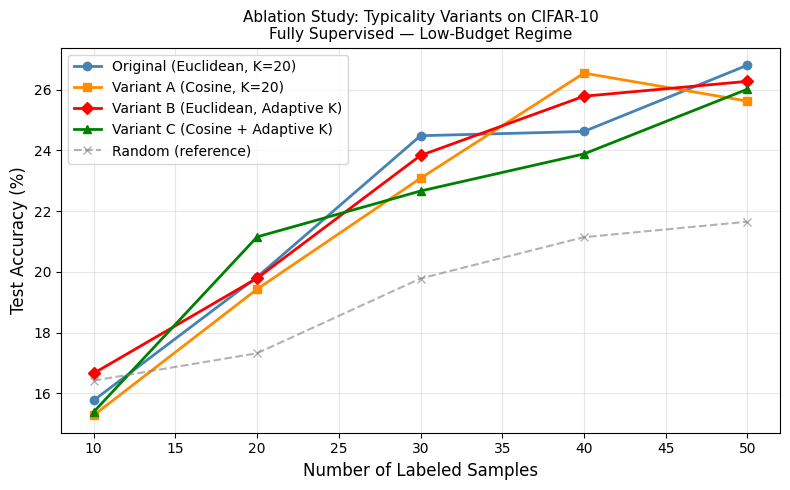

In [59]:
# Plot all four variants together for comparison
original_labeled = [r["labelled"] for r in results]
original_acc = [r["accuracy"] for r in results]
varA_labeled = [r["labelled"] for r in results_A]
varA_acc = [r["accuracy"] for r in results_A]
varB_labeled = [r["labelled"] for r in results_B]
varB_acc = [r["accuracy"] for r in results_B]
varC_labeled = [r["labelled"] for r in results_C]
varC_acc = [r["accuracy"] for r in results_C]

plt.figure(figsize=(8, 5))
plt.plot(original_labeled, original_acc, marker="o", linewidth=2, color="steelblue",  label="Original (Euclidean, K=20)")
plt.plot(varA_labeled, varA_acc, marker="s", linewidth=2, color="darkorange", label="Variant A (Cosine, K=20)")
plt.plot(varB_labeled, varB_acc, marker="D", linewidth=2, color="red", label="Variant B (Euclidean, Adaptive K)")
plt.plot(varC_labeled, varC_acc, marker="^", linewidth=2, color="green", label="Variant C (Cosine + Adaptive K)")
plt.plot(random_counts, random_accs,marker="x", linewidth=1.5, linestyle="--", color="grey",alpha=0.6, label="Random (reference)")
plt.xlabel("Number of Labeled Samples", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Ablation Study: Typicality Variants on CIFAR-10\n"
          "Fully Supervised — Low-Budget Regime", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tpcrp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
# Print accuracy for all variants per round for easy comparison
print("Accuracy (%) across active learning rounds:\n")
for i in range(5):
    orig = results[i]['accuracy']
    a = results_A[i]['accuracy']
    b = results_B[i]['accuracy']
    c = results_C[i]['accuracy']
    print(f"Round {i+1}: "
          f"Original = {orig:.2f}% | "
          f"Cosine (k=20) = {a:.2f}% | "
          f"Euclidean (adaptive) = {b:.2f}% | "
          f"Cosine (adaptive) = {c:.2f}%")

print("\nDone.")

Accuracy (%) across active learning rounds:

Round 1: Original = 15.77% | Cosine (k=20) = 15.28% | Euclidean (adaptive) = 16.66% | Cosine (adaptive) = 15.39%
Round 2: Original = 19.83% | Cosine (k=20) = 19.43% | Euclidean (adaptive) = 19.79% | Cosine (adaptive) = 21.15%
Round 3: Original = 24.48% | Cosine (k=20) = 23.08% | Euclidean (adaptive) = 23.83% | Cosine (adaptive) = 22.66%
Round 4: Original = 24.62% | Cosine (k=20) = 26.54% | Euclidean (adaptive) = 25.78% | Cosine (adaptive) = 23.88%
Round 5: Original = 26.80% | Cosine (k=20) = 25.62% | Euclidean (adaptive) = 26.27% | Cosine (adaptive) = 26.01%

Done.


# Conclusion
The TPCRP algorithm showed consistent improvement in accuracy across active learning rounds, increasing from around 11.8% to 22.7% as more samples were labelled. This confirms that typicality-based sampling is effective in low-budget settings.

The ablation study showed that cosine distance provided the most consistent improvements over the original Euclidean approach, suggesting it better matches SimCLR embeddings. Adaptive K achieved strong final performance but was less stable, and combining both changes did not improve results.

A key limitation is the use of only 50 SimCLR epochs instead of 500, which likely reduced embedding quality and overall performance.

Overall, the results support TPCRP and show that the choice of distance metric significantly impacts performance.

## Code Repository

The full implementation is available at the following GitHub repository: [GitHub Repository Link](https://github.com/llayan-1/typiclust-cw2.git)